<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSGE603130 • Kecerdasan Artifisial dan Sains Data Dasar

Semester Gasal 2023/2024

Fakultas Ilmu Komputer, Universitas Indonesia

# *Proyek Akhir KASDAD Kelompok Data+*: Valorant Pro Matches (VPM)


## Kelompok
| Nama | NPM |
|---|---|
| Lyzander Marciano Andrylie | 2106750755 |
| Muhammad Hafizha Dhiyaulhaq | 2106750723 |
| Felix Tjahyadi | 2106638614 |

 

## Deskripsi Proyek Akhir

**Valorant** adalah ***5v5 team-based first-person tactical hero shooter*** yang dikembangkan dan dipublikasikan oleh Riot Games. Pada game ini, pemain akan menggunakan salah satu ***agent***/karakter dengan kemampuan unik. Masing-masing *agent* akan memiliki peran tertentu dalam tim: *Duelists*, *Sentinels*, *Initiators*, and *Controllers*.

Pada saat permainan dimulai, 5 pemain dalam 1 tim akan berperan sebagai tim penyerang dan 5 pemain lainnya dalam 1 tim akan berperan sebagai tim bertahan secara bergiliran. Tim penyerang menang pada suatu ronde jika dan hanya jika *spike* yang ditanam pada lokasi bom meledak dan/atau kelima pemain dari tim bertahan berhasil dikalahkan. Di sisi lain, Tim bertahan menang pada suatu ronde jika dan hanya jika *spike* yang telah ditanam pada lokasi bom berhasil dijinakkan, kelima pemain dari tim penyerang berhasil dikalahkan dengan *spike* yang tidak meledak, atau waktu ronde habis. Berkaitan dengan permainan, suatu permainan akan berlangsung dalam 13 ronde atau lebih jika belum memenuhi kondisi *win by two*. Suatu permainan dimenangkan oleh suatu tim jika dan hanya jika tim memenangkan 13 ronde atau lebih dengan selisih kemenangan 2 ronde atau lebih dari tim yang kalah sedemikian hingga kondisi *win by two* terpenuhi. 

Seiring dengan meningkatnya kepopuleran dari Valorant, Valorant memiliki kancah esports yang aktif. Pada kancah ini, banyak turnamen yang telah diselenggarakan dan diikuti oleh berbagai tim dari belahan dunia dengan hadiah kemenangan yang besar. Dengan demikian, pada proyek ini, kami ingin menganalisis data pertandingan dari *Valorant Pro Matches* dan membuat model *machine learning* yang sesuai. Berikut adalah ketentuan model machine learning yang akan dibuat.

-  Lakukan klasifikasi untuk menentukan Agent yang digunakan oleh setiap pemain pada setiap babak!
-  Buatlah model untuk memprediksi nilai rata-rata ACS dari masing-masing tim untuk sebuah pertandingan!
-  Lakukan clustering pada dataset, dan berikan analisis dan insight yang kaliat dapatkan dari cluster yang dibuat.

## Dependesi Proyek

### Import Libraries

In [1]:
import warnings
import random
from datetime import datetime
import re
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# sns color palette
palette_agent_role = {
    "duelists": "#FF4654",
    "initiators": "#5B4E77",
    "controllers": "#64A0B3",
    "sentinels": "#FFB94E",
}

# Remove warning
warnings.simplefilter(action='ignore', category=FutureWarning)

### Utility Function

In [2]:
def merge_datasets(df_matches, df_games, df_scores):
    df_matches_games = pd.merge(df_matches, df_games, on=['MatchID', 'Team1ID', 'Team2ID'])
    df_matches_games_scores = pd.merge(df_matches_games, df_scores, on=['GameID'])
    return df_matches_games_scores

class Transformer:
    def transform(self, data: pd.DataFrame):
        '''
        Implementasi berupa prosedur (Facade pattern) untuk men-transform test dataset `*_test.csv` ke dalam
        bentuk yang dapat diproses secara langsung oleh model machine learning yang telah dibuat.
        '''
        pass


class MatchesUtils(Transformer):
    '''
    Utility class untuk dataset `matches.csv`
    '''

    def transform(self, data: pd.DataFrame):
        pass

    def patch_transform(self, df: pd.DataFrame):
        def patch_transform(x):
            regex = r"(?<=Patch\s)\d"
            match = re.search(regex, x)
            return match.group() if match else x

        df['Patch'] = df['Patch'].map(patch_transform, na_action='ignore')

    def patch_impute(self, df_matches: pd.DataFrame, df_patch_date_range: pd.DataFrame):
        '''
        Imputasi Kolom `Patch` berdasarkan tanggal `Date` dari suatu pertandingan
        '''

        def patch_imputer(row):
            if not pd.isna(row['Patch']):
                return row['Patch']

            row_date_obj = datetime.strptime(row['Date'], "%Y-%m-%d")

            # Pengecekan `Date` berdasarkan nilai paling min
            lowest_patch_min_date = df_patch_date_range['Date']['min'].min()
            lowest_patch_min_date_obj = datetime.strptime(
                lowest_patch_min_date, "%Y-%m-%d")

            if row_date_obj < lowest_patch_min_date_obj:
                return df_patch_date_range['Date']['min'].idxmin()

            # Pengecekan `Date` berdasarkan range `df_patch_date_range`
            for patch, date_range in df_patch_date_range.iterrows():
                patch_min_date = date_range['Date']['min']
                patch_max_date = date_range['Date']['max']

                patch_min_date_obj = datetime.strptime(
                    patch_min_date, "%Y-%m-%d")
                patch_max_date_obj = datetime.strptime(
                    patch_max_date, "%Y-%m-%d")

                # Pengecekan `Date` dari suatu pertandingan untun menentukan Patch
                if patch_min_date_obj <= row_date_obj <= patch_max_date_obj:
                    return patch

            return row['Patch']

        df_matches['Patch'] = df_matches[['Date', 'Patch']].apply(
            patch_imputer, axis='columns')

    def date_impute(self, df: pd.DataFrame):
        def date_imputer(x):
            date, *_ = x.split()
            return date

        df['Date'] = df['Date'].map(date_imputer, na_action='ignore')


class GamesUtils(Transformer):
    '''
    Utility class untuk dataset `games.csv`
    '''

    def transform(self, data: pd.DataFrame):
        pass


class ScoresUtils(Transformer):
    '''
    Utility class untuk dataset `scores.csv`
    '''

    def transform(self, data: pd.DataFrame):
        pass

    def player_id_impute(self, df: pd.DataFrame):
        id_counter = df['PlayerID'].max() + 1
        player_ids = {}

        def player_id_imputer(row):
            nonlocal id_counter, player_ids

            if pd.isnull(row['PlayerID']):
                if row['PlayerName'] in player_ids:
                    return player_ids[row['PlayerName']]

                player_ids[row['PlayerName']] = id_counter
                id_counter += 1
                return player_ids[row['PlayerName']]

            return row['PlayerID']

        df['PlayerID'] = df[['PlayerID', 'PlayerName']].apply(
            player_id_imputer, axis='columns')

    def agent_impute(self, df: pd.DataFrame, df_merge, srs_most_used_hero_by_player):
        random.seed(1000)
        df_game_id_patch = df_merge[['GameID', 'Patch']]

        def agent_imputer(row):
            patch_nums = df_game_id_patch.loc[df_game_id_patch['GameID'] == row['GameID'], 'Patch']

            if (not pd.isnull(row['Agent'])) or len(patch_nums) == 0:
                return row['Agent']
            
            # Imputasi berdasarkan agent yang paling sering dimainkan
            agent = srs_most_used_hero_by_player[row['PlayerID'], patch_nums.iloc[0]]

            if isinstance(agent, str):
                return agent
            elif isinstance(agent, np.ndarray) and len(agent) >= 2:
                return agent[random.randint(0, len(agent)-1)]

            return row['Agent']

        df['Agent'] = df[['PlayerID', 'Agent', 'GameID']].apply(
            agent_imputer, axis='columns')


# Objek utility
util_matches = MatchesUtils()
util_games = GamesUtils()
util_scores = ScoresUtils()

## Dataset

### Deskripsi Dataset

#### Dataset `matches.csv`

Berisi informasi tentang tim yang berpartisipasi dalam sebuah turnamen. Pertandingan umumnya diadakan dengan aturan "best of 3," di mana tim yang memenangkan babak terbanyak akan menjadi pemenang pertandingan.

> **Note:** Pertandingan final diadakan dengan aturan "best of 5"

Jumlah Kolom x Baris: 12 kolom x 6401 baris

Deskripsi Kolom:

1. MatchID : Id pertandingan
2. Date : Tanggal pertandingan
3. Patch : Versi Valorant saat pertandingan dilakukan
4. EventID : Id turnamen
5. EventName : Nama turnamen
6. EventStage : Tahap turnamen
7. Team1ID : Id tim 1
8. Team2ID : Id tim 2
9. Team1 : Nama tim 1
10. Team2 : Nama tim 2
11. Team1_MapScore : Banyak babak yang dimenangkan tim 1
12. Team2_MapScore : Banyak babak yang dimenangkan tim 2

#### Dataset `games.csv`

Mendokumentasikan detail babak yang dimainkan oleh kedua tim yang bersaing dalam turnamen.

Jumlah Kolom x Baris: 18 kolom x 12961 baris

Deskripsi Kolom:

1. GameID : Id babak
2. MatchID : Id pertandingan
3. Map : Peta yang digunakan
4. Team1ID : Id tim 1
5. Team2ID : Id tim 2
6. Team1 : Nama tim 1
7. Team2 : Nama tim 2
8. Winner : Tim yang menjadi pemenang
9. Team1_Eco : Banyak ronde eco yang dilakukan tim 1
10. Team1_SemiEco : Banyak ronde semi eco yangdilakukan tim 1
11. Team1_SemiBuy : Banyak ronde semi buy yangdilakukan tim 1
12. Team1_FullBuy : Banyak ronde full buy yang dilakukan tim 1
13. Team1_TotalRounds : Banyak ronde yang dimenangkan tim 1
14. Team2_Eco : Banyak ronde eco yang dilakukan tim 2
15. Team2_SemiEco : Banyak ronde semi eco yang dilakukan tim 2
16. Team2_SemiBuy : Banyak ronde semi buy yang dilakukan tim 2
17. Team2_FullBuy : Banyak ronde full buy yang dilakukan tim 2
18. Team2_TotalRounds : Banyak ronde yang dimenangkan tim 2

> **Note:** Valorant Economy Guide: <https://www.ign.com/wikis/valorant/Valorant_Economy_Guide>
> Penting untuk tahap pemahaman data.

#### Dataset `scores.csv`

Merupakan catatan akhir dari status para pemain profesional yang bertanding dalam babak tersebut

Jumlah Kolom x Baris: 28 kolom x 128779 baris

Deskripsi Kolom:

1. GameID : Id babak
2. PlayerID: Id pemain
3. PlayerName : Username pemain
4. TeamAbbreviation : Singkatan nama tim
5. Agent : Agent/karakter yang digunakan
6. ACS : Skor rata-rata dari pemain
7. Kills : Jumlah musuh yang dikalahkan
8. Deaths : Total pemain berhasil dieliminasi
9. Assists : Jumlah kontribusi pemain dalam membantu rekannya untuk mengalahkan musuh
10. PlusMinus : Selisih antara jumlah mengalahkan musuh (Kills) dan jumlah tereliminasi (Deaths)
11. KAST_Percent : Besar kontribusi pemain dalam pertandingan
12. ADR : Rata-rata serangan yang diberikan oleh pemain ke pihak musuh
13. HS_Percent : Persentase serangan yang diberikan mengenai kepala musuh
14. FirstKills : Total pemain berhasil melakukan eliminasi pertama kali pada suatu ronde
15. FirstDeaths : Total pemain dieliminasi pertama kali pada suatu ronde
16. FKFD_PlusMinus : Selisih antara jumlah First Kills dan First Deaths
17. Num_2Ks, Num_3ks, Num_4ks, Num_5ks : Jumlah pemain berhasil mengeliminasi X musuh dalam suatu ronde
18. OnevOne, OnevTwo, OnevThree, OnevFour, OnevFive : Jumlah pemain berhasil mengalahkan X musuh pada suatu timeframe
19. Econ : Besar serangan yang dihasilkan untuk setiap 1000 creds (mata uang pada permainan) yang digunakan untuk membeli perlengkapan
20. Plants : Jumlah pemain berhasil menanam spike (bom) pada suatu ronde
21. Defuses : Jumlah pemain berhasil menjinakkan spike (bom) pada suatu ronde

> **Notes:** Valorant Key Metric: <https://digitalgamersdream.com/key-metrics-for-analyzing-valorant-matches/>
> Penting untuk pemahaman terkait metric-metric tertentu, seperti ACS (Average Combat Score) dan KAST.

> Num_5ks = Ace

#### Dataset `agent_encode.csv`

Label encoding dari nama agent di Valorant.

Jumlah Kolom x Baris: 2 kolom x 17 baris

Deskripsi Kolom:

1. Agent: nama karakter
2. Encode: hasil encoding

#### Dataset `agent_role.csv`

Kategori dari agent-agent pada valorant

Jumlah Kolom x Baris: 2 kolom x 17 baris

Deskripsi Kolom:

1. Agent: nama karakter
2. Role: peran karakter

Kategori Kolom Role:

1. controllers: agen-agen dengan tipe ini dapat memblokir area tertentu di peta untuk mempermudah serangan atau pertahanan, serta mengontrol alur permainan.
2. duelists: agen-agen dengan tipe ini bersifat ofensif dan unggul dalam pertarungan satu lawan satu yang bertujuan untuk menerobos pertahanan musuh dan memenangkan duel.
3. initiators: agen-agen dengan tipe ini berfungsi sebagai pendukung dan sangat cocok untuk memulai pertarungan dan membantu tim Anda memenangkannya. Agen ini biasanya memiliki kemampuan yang memungkinkan mereka memberikan informasi kepada tim, atau mengacaukan musuh. 
4. sentinels: agen-agen dengan tipe ini bersifat defensif dan biasanya memperlambat, mengulur waktu, atau terkadang langsung menghentikan serangan musuh di area tertentu di peta.

### Read Dataset

#### Dataset `matches.csv`

In [3]:
df_matches = pd.read_csv('./dataset/matches.csv')
df_matches.head()

,No,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1,Team2,Team1_MapScore,Team2_MapScore
0,0,62393,2022-01-08 15:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,Pho Real,2,1
1,1,62403,2022-01-08 15:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (C),7046,7047,Bjor's Kittens,Mugiwara,2,0
2,2,62391,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (A),6461,6903,Akrew,Booster Seat Gaming,2,1
3,3,62396,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (B),6164,7043,Radiance,sameROFLMAO,2,0
4,5,62402,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Elimination (C),7047,3545,Mugiwara,CLG Red,2,0


In [4]:
df_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6401 entries, 0 to 6400
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   No              6401 non-null   int64 
 1   MatchID         6401 non-null   int64 
 2   Date            6401 non-null   object
 3   Patch           5990 non-null   object
 4   EventID         6401 non-null   int64 
 5   EventName       6401 non-null   object
 6   EventStage      6401 non-null   object
 7   Team1ID         6401 non-null   int64 
 8   Team2ID         6401 non-null   int64 
 9   Team1           6401 non-null   object
 10  Team2           6401 non-null   object
 11  Team1_MapScore  6401 non-null   int64 
 12  Team2_MapScore  6401 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 650.2+ KB


In [5]:
df_matches.duplicated().sum()

0

#### Dataset `games.csv`

In [6]:
df_games = pd.read_csv('./dataset/games.csv')
df_games.head()

,No,GameID,MatchID,Map,Team1ID,Team2ID,Team1,Team2,Winner,Team1_Eco,Team1_SemiEco,Team1_SemiBuy,Team1_FullBuy,Team1_TotalRounds,Team2_Eco,Team2_SemiEco,Team2_SemiBuy,Team2_FullBuy,Team2_TotalRounds
0,0,60894,62393,Breeze,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,0.0,5.0,13.0,13,4.0,2.0,4.0,10.0,7
1,1,60895,62393,Bind,6903,6020,Booster Seat Gaming,Pho Real,2,3.0,3.0,5.0,4.0,2,2.0,0.0,4.0,9.0,13
2,2,60896,62393,Haven,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,2.0,5.0,12.0,13,2.0,2.0,6.0,11.0,8
3,3,60924,62403,Icebox,7046,7047,Bjor's Kittens,Mugiwara,1,2.0,2.0,4.0,11.0,13,4.0,1.0,2.0,12.0,6
4,4,60925,62403,Haven,7046,7047,Bjor's Kittens,Mugiwara,1,4.0,2.0,3.0,13.0,13,3.0,3.0,4.0,12.0,9


In [7]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12961 entries, 0 to 12960
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No                 12961 non-null  int64  
 1   GameID             12961 non-null  int64  
 2   MatchID            12961 non-null  int64  
 3   Map                12961 non-null  object 
 4   Team1ID            12961 non-null  int64  
 5   Team2ID            12961 non-null  int64  
 6   Team1              12961 non-null  object 
 7   Team2              12961 non-null  object 
 8   Winner             12961 non-null  int64  
 9   Team1_Eco          11927 non-null  float64
 10  Team1_SemiEco      11927 non-null  float64
 11  Team1_SemiBuy      11927 non-null  float64
 12  Team1_FullBuy      11927 non-null  float64
 13  Team1_TotalRounds  12961 non-null  int64  
 14  Team2_Eco          11927 non-null  float64
 15  Team2_SemiEco      11927 non-null  float64
 16  Team2_SemiBuy      119

In [8]:
df_games.duplicated().sum()

0

#### Dataset `scores.csv`

In [9]:
df_scores = pd.read_csv('./dataset/scores.csv')
df_scores.head()

,No,GameID,PlayerID,PlayerName,TeamAbbreviation,Agent,ACS,Kills,Deaths,Assists,...,Num_4Ks,Num_5Ks,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses
0,0,60894,8419.0,Reduxx,Boos,jett,313.0,24.0,10.0,3.0,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0
1,1,60894,466.0,ChurmZ,Boos,chamber,227.0,16.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0
2,2,60894,3712.0,diaamond,Boos,sova,226.0,17.0,9.0,8.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0
3,3,60894,5099.0,Boltzy,Boos,viper,218.0,17.0,12.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0
4,4,60894,3983.0,Virtyy,Boos,skye,80.0,5.0,13.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0


In [10]:
df_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128779 entries, 0 to 128778
Data columns (total 29 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   No                128779 non-null  int64  
 1   GameID            128779 non-null  int64  
 2   PlayerID          128692 non-null  float64
 3   PlayerName        128779 non-null  object 
 4   TeamAbbreviation  126763 non-null  object 
 5   Agent             124679 non-null  object 
 6   ACS               128249 non-null  float64
 7   Kills             128289 non-null  float64
 8   Deaths            128289 non-null  float64
 9   Assists           128289 non-null  float64
 10  PlusMinus         127026 non-null  float64
 11  KAST_Percent      2637 non-null    float64
 12  ADR               119904 non-null  float64
 13  HS_Percent        119307 non-null  float64
 14  FirstKills        128249 non-null  float64
 15  FirstDeaths       119314 non-null  float64
 16  FKFD_PlusMinus    11

In [11]:
df_scores.duplicated().sum()

0

#### Dataset Agent

##### Dataset `agent_encode.csv`

In [12]:
# Read and drop the first column
df_agent_encode = pd.read_csv('./dataset/agent_encode.csv')
df_agent_encode.drop(df_agent_encode.columns[0], axis='columns', inplace=True)
df_agent_encode.head()

,Agent,Encode
0,jett,0
1,sova,1
2,astra,2
3,kayo,3
4,killjoy,4


##### Dataset `agent_role.csv`

In [13]:
# Read and drop the first column
df_agent_role = pd.read_csv('./dataset/agent_role.csv')
df_agent_role.drop(df_agent_role.columns[0], axis='columns', inplace=True)
df_agent_role.head()

,Agent,Role
0,jett,duelists
1,sova,initiators
2,astra,controllers
3,kayo,initiators
4,killjoy,sentinels


##### Merge Dataset Agent

In [14]:
df_agent = pd.merge(df_agent_encode, df_agent_role)
df_agent

,Agent,Encode,Role
0,jett,0,duelists
1,sova,1,initiators
2,astra,2,controllers
3,kayo,3,initiators
4,killjoy,4,sentinels
5,skye,5,initiators
6,cypher,6,sentinels
7,viper,7,controllers
8,sage,8,sentinels
9,reyna,9,duelists


## Exploratory Data Analysis

### Distribusi Agent Berdasarkan Patch

#### Informasi Kolom `Patch`

In [15]:
df_matches['Patch'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6401 entries, 0 to 6400
Series name: Patch
Non-Null Count  Dtype 
--------------  ----- 
5990 non-null   object
dtypes: object(1)
memory usage: 50.1+ KB


##### Jumlah Null Value

In [16]:
df_matches['Patch'].isnull().sum()

411

##### Informasi Kategori

In [17]:
df_matches['Patch'].value_counts('Patch').sort_index(ascending=False)

Patch
Patch 3.12                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   0.028381
Patch 3.10                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

Perhatikan bahwa value pada kolom `Patch` tidak ringkas, sulit diinterpretasikan, sulit dipahami dan tidak konsisten. Dengan demikian, kita dapat melakukan *data cleaning* sedemikian hingga masalah-masalah pada kolom `Patch` dapat diatasi. 

#### Pemrosesan Kolom Patch

Pemrosesan kolom patch dapat dilakukan dengan memahami format dari nilai pada kolom `Patch`. Bentuk format `Patch` pada game valorant adalah `X.YZ` dengan makna sebagai berikut.

1. `X`: merepresentasikan nomor **episode** yang biasanya berlangsung selama 2 bulan
2. `Y`: merepresentasikan nomor **act** yang biasanya berlansung selama 2 minggu
3. `Z`: merepresentasikan nomor **patch** dalam suatu **act**

Dengan demikian, kita dapat meringkas data berdasarkan nilai `X` sedemikian hingga nilai pada kolom `Patch` mudah dipahami.

In [18]:
util_matches.patch_transform(df_matches)
df_matches['Patch'].value_counts()

Patch
3    2038
2    1959
1    1907
0      86
Name: count, dtype: int64

##### Cek Null Value

In [19]:
df_matches['Patch'].isnull().sum()

411

Perhatikan bahwa masih terdapat 411 pertandingan dengan kolom `Patch` bernilai null. Untuk memperbaiki hal ini, kita dapat melakukan *data imputation* berdasarkan tanggal pertandingan pada kolom `Date`. Hal ini dikarenakan pertandingan yang diselenggarakan pada rentang tanggal tertentu dapat ditentukan kolom `Patch`-nya berdasarkan data yang ada. 

##### Pemrosesan Kolom Date

In [20]:
util_matches.date_impute(df_matches)
df_matches['Date'].value_counts()

Date
2021-11-12    74
2021-11-13    69
2020-12-19    68
2021-07-22    48
2021-10-09    46
              ..
2021-12-16     1
2021-03-23     1
2021-06-01     1
2021-05-31     1
2020-07-21     1
Name: count, Length: 557, dtype: int64

Pemrosesan di atas dilakukan agar kolom `Date` dapat lebih mudah diproses untuk menentukan kolom `Patch` yang akan diimputasi berdasarkan kolom tersebut.

##### Rentang Tanggal Patch

In [21]:
df_patch_date_range = df_matches[['Patch', 'Date']].groupby('Patch').aggregate(['min', 'max'])
df_patch_date_range

Date            
              min         max
Patch                        
0      2020-05-04  2020-06-14
1      2020-06-04  2021-01-24
2      2021-01-13  2021-06-29
3      2021-06-22  2022-01-08

##### Imputasi Data untuk kolom `Patch`

In [22]:
util_matches.patch_impute(df_matches, df_patch_date_range)

Imputasi dilakukan pada baris dengan kolom `Patch` yang bernilai null. Nilai dari kolom tersebut akan ditentukan berdasarkan `Date` dari pertandingan. `Date` dari pertandingan akan dibandingkan dengan rentang tanggal patch (`df_patch_date_range`). Jika suatu pertandingan memiliki `Date` yang berada pada rentang `min Date` dan `max Date` dari suatu `Patch x`, maka kolom `Patch` akan bernilai `x`. Sebagai tambahan, pertandingan dengan `Date` \< `min Date` dari `Patch 0` akan bernilai 0 pada kolom `Patch`-nya. 

##### Cek Null value

In [23]:
df_matches['Patch'].isnull().sum()

0

#### Merge Dataset `matches.csv`, `games.csv`, dan `scores.csv`

##### Cek nilai `MatchID`

In [24]:
matches_match_id_unique = set(df_matches["MatchID"].unique())
games_match_id_unique = set(df_games["MatchID"].unique())

print(f'Nilai Unik MatchID pada matches.csv: {len(matches_match_id_unique)}')
print(f'Nilai Unik MatchID pada games.csv: {len(games_match_id_unique)}')

missing_match_id = matches_match_id_unique.symmetric_difference(games_match_id_unique)
print(f'Jumlah missing MatchID: {len(missing_match_id)}')
print(sorted(missing_match_id))

Nilai Unik MatchID pada matches.csv: 6401
Nilai Unik MatchID pada games.csv: 6356
Jumlah missing MatchID: 45
[1474, 2307, 2308, 2309, 2310, 2319, 2321, 2323, 2326, 2333, 2340, 2341, 2342, 2343, 2345, 2349, 2364, 2375, 2376, 2377, 2379, 2384, 2387, 2388, 2814, 2815, 2817, 2818, 3122, 3232, 3577, 3588, 3592, 3931, 4201, 6901, 7811, 7814, 14043, 16841, 50393, 50441, 50442, 50466, 50467]


##### Cek nilai `GameID`

In [25]:
games_game_id_unique = set(df_games["GameID"].unique())
scores_game_id_unique = set(df_scores["GameID"].unique())

print(f'Nilai Unik GameID pada games.csv: {len(games_game_id_unique)}')
print(f'Nilai Unik GameID pada scores.csv: {len(scores_game_id_unique)}')

missing_game_id = games_game_id_unique.symmetric_difference(scores_game_id_unique)
print(f'Jumlah missing GameID: {len(missing_game_id)}')
print(sorted(missing_game_id))

Nilai Unik GameID pada games.csv: 12961
Nilai Unik GameID pada scores.csv: 12962
Jumlah missing GameID: 19
[559, 759, 796, 6995, 10612, 20743, 21350, 23100, 31931, 36231, 36689, 44237, 49043, 49107, 53321, 53322, 57193, 60567, 60644]


##### Merge Dataset 

Berdasarkan pengecekan nilai yang telah dilakukan, kita dapat mengetahui bahwa `MatchID` dan `GameID` yang merupakan **primary key** pada dataset `games.csv`, `matches.csv`, dan `scores.csv` terdapat perbedaan. Dengan demikian, hasil *merge* yang dilakukan akan berdasarkan *primary key* saja dan akan ada beberapa data yang hilang.

In [26]:
df_matches_games_scores = merge_datasets(df_matches, df_games, df_scores)

# Fungsi untuk mensinkronkan hasil merge
def remerge_dataset():
    global df_matches_games_scores
    df_matches_games_scores = merge_datasets(df_matches, df_games, df_scores)

df_matches_games_scores.head()

,No_x,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1_x,...,Num_4Ks,Num_5Ks,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses
0,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0
1,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0
2,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0
3,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0
4,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0


#### Imputasi Data untuk kolom `Agent`

##### Cek Kolom Agent pada `df_scores`

In [27]:
df_scores['Agent'].isnull().sum()

4100

Kita harus melakukan data imputation terlebih dahulu sehingga nilai null pada kolom `Agent` dapat dikurangi. Hal ini dapat dilakukan dengan menggunakan modus dari `Agent` berdasarkan pemain dengan `PlayerID` tertentu (Agent yang paling sering dimainkan oleh pemain pada turnamen).

##### Cek Player ID dan PlayerName

In [28]:
print(f'Jumlah PlayerID yang unik: {len(df_scores["PlayerID"].unique())}')
print(f'Jumlah PlayerName yang unik: {len(df_scores["PlayerName"].unique())}')
print()

print('Jumlah Null dari PlayerID dan PlayerName')
df_scores[['PlayerID', 'PlayerName']].isnull().sum()

Jumlah PlayerID yang unik: 8008
Jumlah PlayerName yang unik: 7895

Jumlah Null dari PlayerID dan PlayerName


PlayerID      87
PlayerName     0
dtype: int64

In [29]:
# Imputasi kolom `PlayerID` dengan id unik
util_scores.player_id_impute(df_scores)
df_scores[['PlayerID', 'PlayerName']].isnull().sum()

# remerge dataset
remerge_dataset()

Imputasi pada kolom `PlayerID` dilakukan dengan memberikan `ID` unik pada pemain dengan `PlayerName` tertentu. Hal ini diperlukan agar kita dapat mengidentifikasikan pemain berdasarkan `PlayerID`-nya.

##### Modus Agent dari setiap Pemain berdasarkan `PlayerID` dan `Patch`

In [30]:
srs_most_used_hero_by_player = df_matches_games_scores[['PlayerID', 'Patch', 'Agent',]].groupby(['PlayerID', 'Patch'])['Agent'].agg(pd.Series.mode)
srs_most_used_hero_by_player

PlayerID  Patch
2.0       0          omen
          1        cypher
          2          jett
          3          sova
3.0       0        breach
                    ...  
22035.0   0            []
22036.0   0            []
22037.0   0            []
22038.0   0            []
22039.0   0            []
Name: Agent, Length: 12750, dtype: object

Kita dapat mengabaikan player yang tidak memiliki modus `Agent`. Perhatikan bahwa, pada tahap *Preprocessing*, kita akan memperbaiki lebih lanjut untuk dataset yang digunakan.

In [31]:
df_matches_games_scores[['PlayerID', 'Patch', 'Agent']].groupby(['PlayerID', 'Patch']).value_counts()

PlayerID  Patch  Agent    
2.0       0      omen          2
          1      cypher       25
                 omen          8
                 raze          7
                 phoenix       4
                              ..
22031.0   1      sova          1
22032.0   1      reyna         2
                 raze          1
22033.0   1      cypher        1
22034.0   1      brimstone     1
Name: count, Length: 29786, dtype: int64

##### Perbaikan Kolom `Agent` Pemain bedasarkan Modus Agent

In [32]:
util_scores.agent_impute(df_scores, df_matches_games_scores, srs_most_used_hero_by_player)

# remerge dataset
remerge_dataset()

df_scores['Agent'].isnull().sum()

Imputasi dilakukan pada kolom `Agent` berdasarkan Agent yang paling sering dimainkan oleh pemain pada turnamen pada `Patch` tertentu. Hal ini dikarenakan setiap pemain memiliki kecenderungan untuk memiliki main agent. Main agent adalah agent yang paling sering digunakan dan dikuasai oleh seorang pemain. Dengan demikian, masuk akal jika kita melakukan imputasi berdasarkan main agent.

> Sisa `Agent` yang bernilai null dapat diabaikan karena tidak bisa ditentukan sama sekali berdasarkan data yang ada.
> Grouping dengan patch perlu dilakukan karena ada `Agent` tertentu yang baru tersedia pada `Patch` tertentu.

#### Visualisasi Distribusi Agent

##### Persentase Agent berdasarkan `Patch`

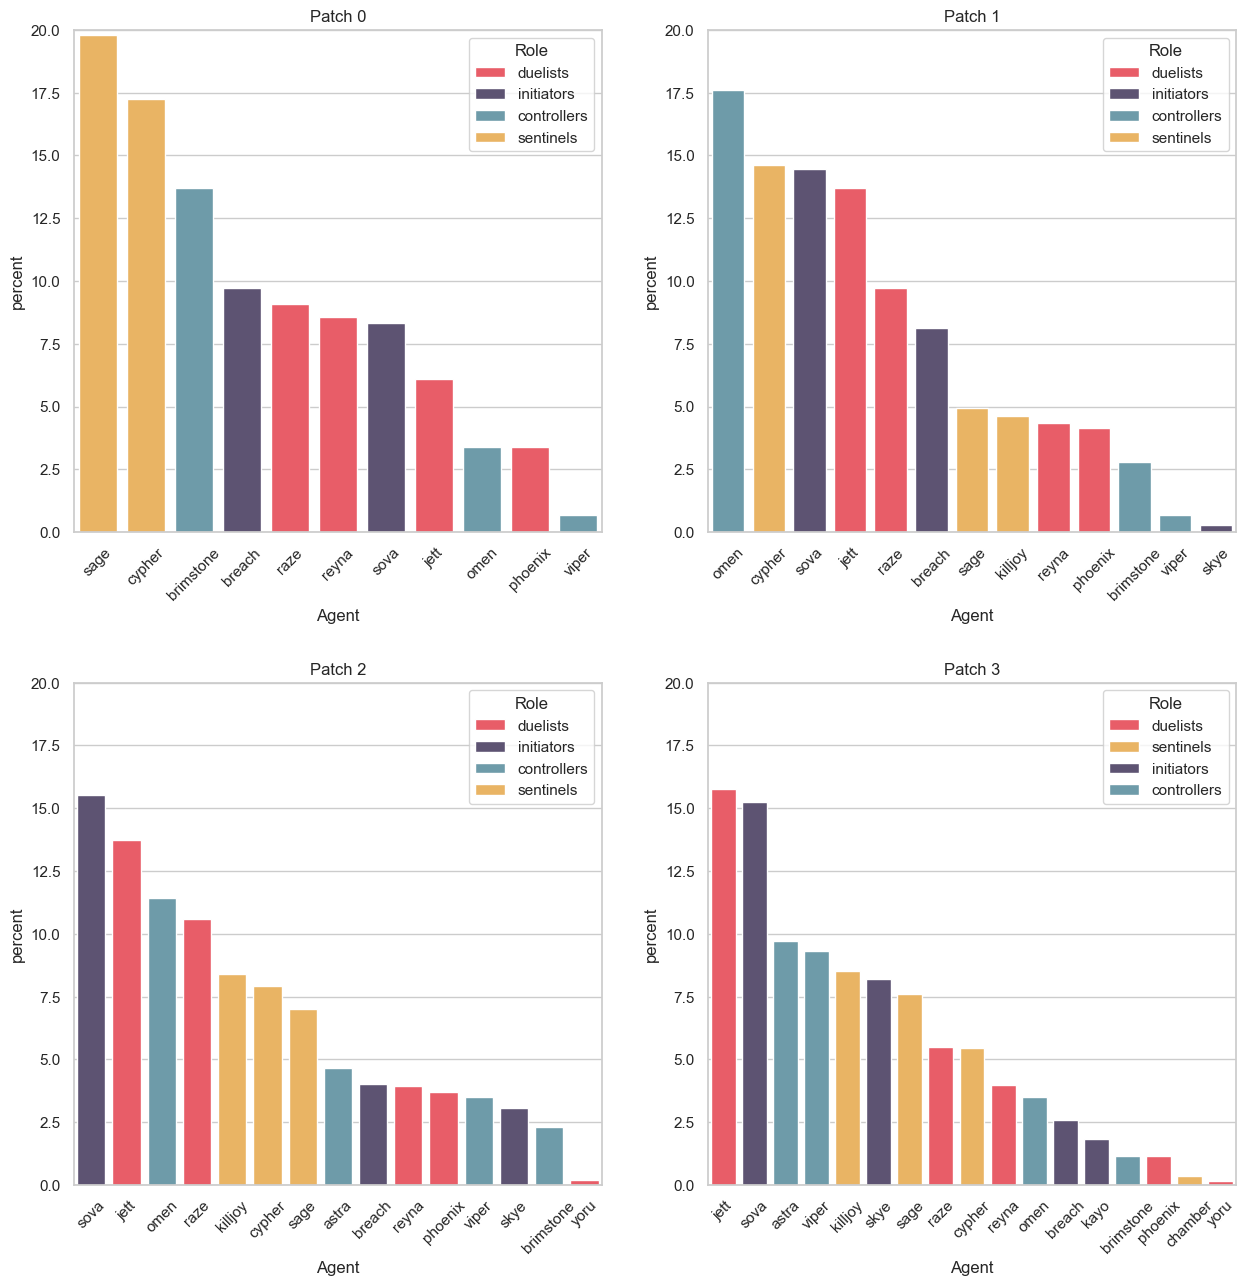

In [49]:
df_agent_patch = pd.merge(
    df_matches_games_scores[['Patch', 'Agent']],
    df_agent[['Agent', 'Role']],
    on='Agent')

patch_nums = sorted(df_agent_patch['Patch'].unique().astype(int))

lst_df_agent_patch = [
    df_agent_patch.query(f'Patch == "{patch_num}"') for patch_num in patch_nums
]

# Countplot
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)
axes = [(0, 0), (0, 1), (1, 0), (1, 1)]

for patch_num in patch_nums:
    current_axs = axs[axes[patch_num]]
    sns.countplot(lst_df_agent_patch[patch_num], x='Agent', hue='Role', ax=current_axs,
                  stat='percent', palette=palette_agent_role, order=lst_df_agent_patch[patch_num]['Agent'].value_counts().index)
    
    # Menyesuaikan plot
    current_axs.set_title(f'Patch {patch_num}')
    current_axs.tick_params(axis='x', labelrotation=45)
    current_axs.set_ylim(0, 20)

Distribusi Agent yang digunakan oleh pemain untuk setiap Patch 0.X, 1.X, 2.X, dan 3.X cukup bervariasi. Berdasarkan data di atas, kita mengetahui bahwa masing-masing patch memiliki `Agent` yang paling sering digunakan dalam pertandingan.

##### Jumlah Agent berdasarkan Patch

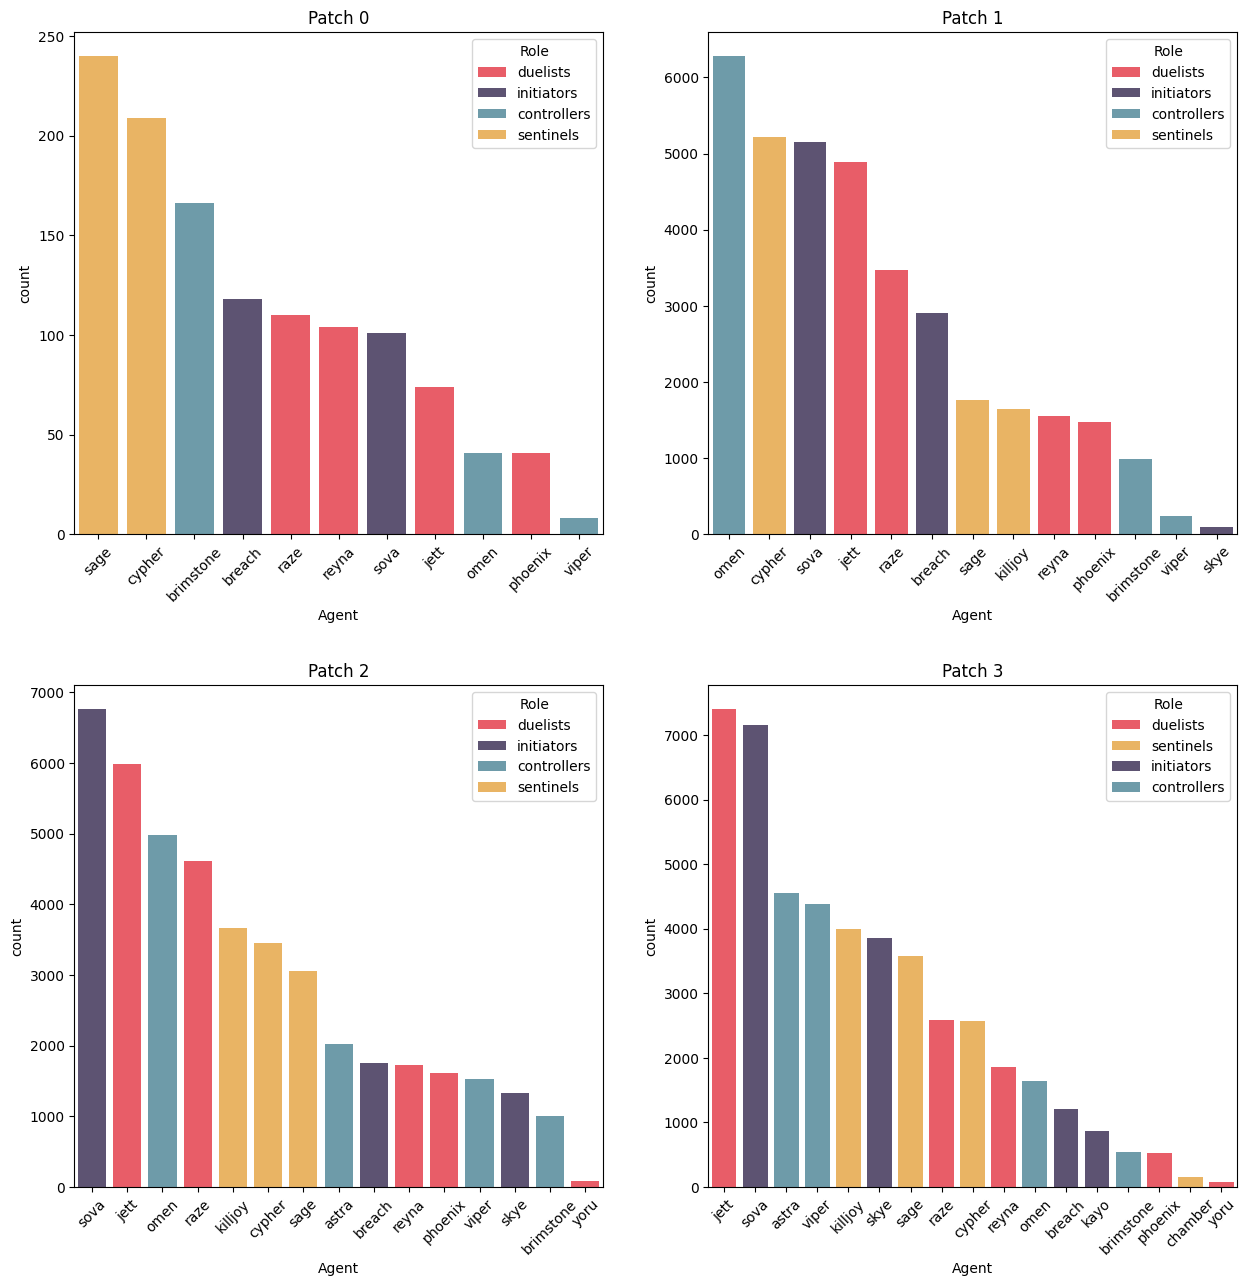

In [34]:
# Countplot
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)
axes = [(0, 0), (0, 1), (1, 0), (1, 1)]

for patch_num in patch_nums:
    current_axs = axs[axes[patch_num]]
    sns.countplot(lst_df_agent_patch[patch_num], x='Agent', hue='Role', ax=current_axs,
                  stat='count', palette=palette_agent_role, order=lst_df_agent_patch[patch_num]['Agent'].value_counts().index)

    # Menyesuaikan plot
    current_axs.set_title(f'Patch {patch_num}')
    current_axs.tick_params(axis='x', labelrotation=45)

Distribusi Agent yang digunakan oleh pemain untuk setiap Patch 0.X, 1.X, 2.X, dan 3.X cukup bervariasi. Berdasarkan data di atas, kita mengetahui bahwa masing-masing patch memiliki `Agent` yang paling sering digunakan dalam pertandingan.

##### Trend Agent berdasarkan `Patch`

## Data Preprocessing

## Modeling and Evaluation

## Sumber Referensi

1. https://en.wikipedia.org/wiki/Valorant
2. https://www.ign.com/wikis/valorant/Concepts:_Roles_in_Valorant
3. https://valorant.fandom.com/wiki/Patch_Notes